<a href="https://colab.research.google.com/github/Kadakol/ML/blob/master/micrograd/Micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
  return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

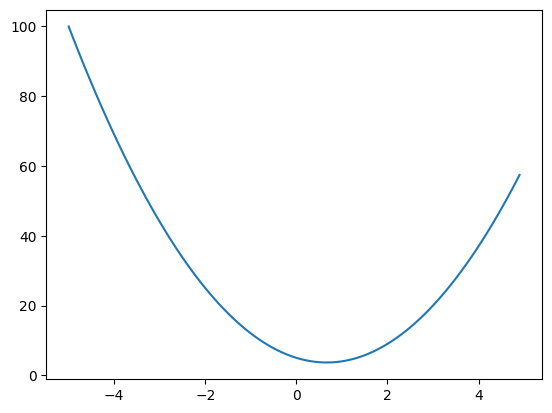

In [4]:
xs = np.arange(-5.0, 5.0, 0.1)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 1e-12
x = 3.0
(f(x+h) - f(x)) / h

14.001244608152774

In [6]:
h = 1e-12
x = -3.0
(f(x+h) - f(x))/h

-21.9984030991327

In [7]:
h = 1e-12
x = 2/3
(f(x+h) - f(x))/h

-0.0004440892098500626

In [8]:
a = 2
b = -3
c = 10
d = a*b + c
print(d)

4


In [9]:
h = 1e-5

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print(f'd1 : {d1}')
print(f'd2 : {d2}')
print(f'slope : {(d2-d1)/h}')

d1 : 4.0
d2 : 3.9999699999999994
slope : -3.000000000064062


In [10]:
h = 1e-5

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print(f'd1 : {d1}')
print(f'd2 : {d2}')
print(f'slope : {(d2-d1)/h}')

d1 : 4.0
d2 : 4.00002
slope : 2.0000000000131024


In [11]:
h = 1e-5

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print(f'd1 : {d1}')
print(f'd2 : {d2}')
print(f'slope : {(d2-d1)/h}')

d1 : 4.0
d2 : 4.00001
slope : 0.9999999999621422


In [12]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f'Value(data={self.data})'

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    return out



a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

print(a + b)
print(a * b)
print(a * b + c)

Value(data=-1.0)
Value(data=-6.0)
Value(data=4.0)


In [13]:
d = a * b + c
print(d)
print(d._prev)
print(d._op)

Value(data=4.0)
{Value(data=10.0), Value(data=-6.0)}
+


In [14]:
e = a*b; e.label='e'
d = e + c; d.label='d'
f = Value(-2.0, label='f')
L = d * f; L.label='L'

print(L)

Value(data=-8.0)


In [15]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
  """
  format: png | svg | ...
  rankdir: TB (top to bottom graph) | LR (left to right)
  """
  assert rankdir in ['LR', 'TB']
  nodes, edges = trace(root)
  dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

  for n in nodes:
    dot.node(name=str(id(n)), label = "{ %s | data %.4f }" % (n.label, n.data), shape='record')
    if n._op:
      dot.node(name=str(id(n)) + n._op, label=n._op)
      dot.edge(str(id(n)) + n._op, str(id(n)))

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

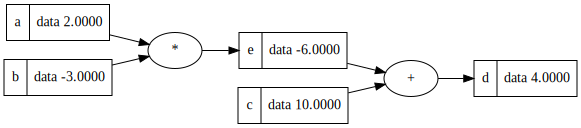

In [16]:
draw_dot(d)